In [12]:
from data_generator import simulate_gbm
from scripts.utils import plot_episode_history_v2
from scripts.variable_leverage_env_3 import agentDLVEnvV3
from leverage_sim import naiveAgent
from model.torch_model_v2 import reccurentActor

In [13]:
model = reccurentActor()
model.set_initial_state('model/actor_weights_v2.pth')

In [14]:
SIGMA = 0.2

s1, _ = simulate_gbm(
    4000,
    1/250,
    1,
    0,
    0.001
)

s2, _ = simulate_gbm(
    4000,
    1/250,
    1,
    0,
    SIGMA
)

s3, _ = simulate_gbm(
    4000,
    1/250,
    1,
    0,
    1.5*SIGMA
)

s, _ = simulate_gbm(
    4000,
    1/250,
    1,
    0,
    2*SIGMA
)

nect_price = 0.5*s1
nav = 20*s3
vol_token_price = 2*s2
volatile_part = s2/(s2 + s)

In [15]:
eval_env = agentDLVEnvV3(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_training = False,
    is_mixed = False,
    is_reversed = False,
    show_setup = False,
    top_leverage= 2.2,
    bottom_leverage = 1.8
)

obs, _ = eval_env.reset()
done = False

while not done:
    action = naiveAgent(obs)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

history_agent = info['episode_history']
not_doing = info.get('0 action')  
action_1 = info.get('0.5 rebalancing') 
action_2 = info.get('0.75 rebalancing') 
action_3 = info.get('0.25 rebalancing') 

print('doing nothing', not_doing*100, '%')
print('action 1', action_1*100, '%')
print('action 2', action_2*100, '%')
print('action 3', action_3*100, '%')

doing nothing 97.075 %
action 1 2.9250000000000003 %
action 2 0.0 %
action 3 0.0 %


doing nothing 91.825 %
action 1 7.9 %
action 2 0.025 %
action 3 0.25 %


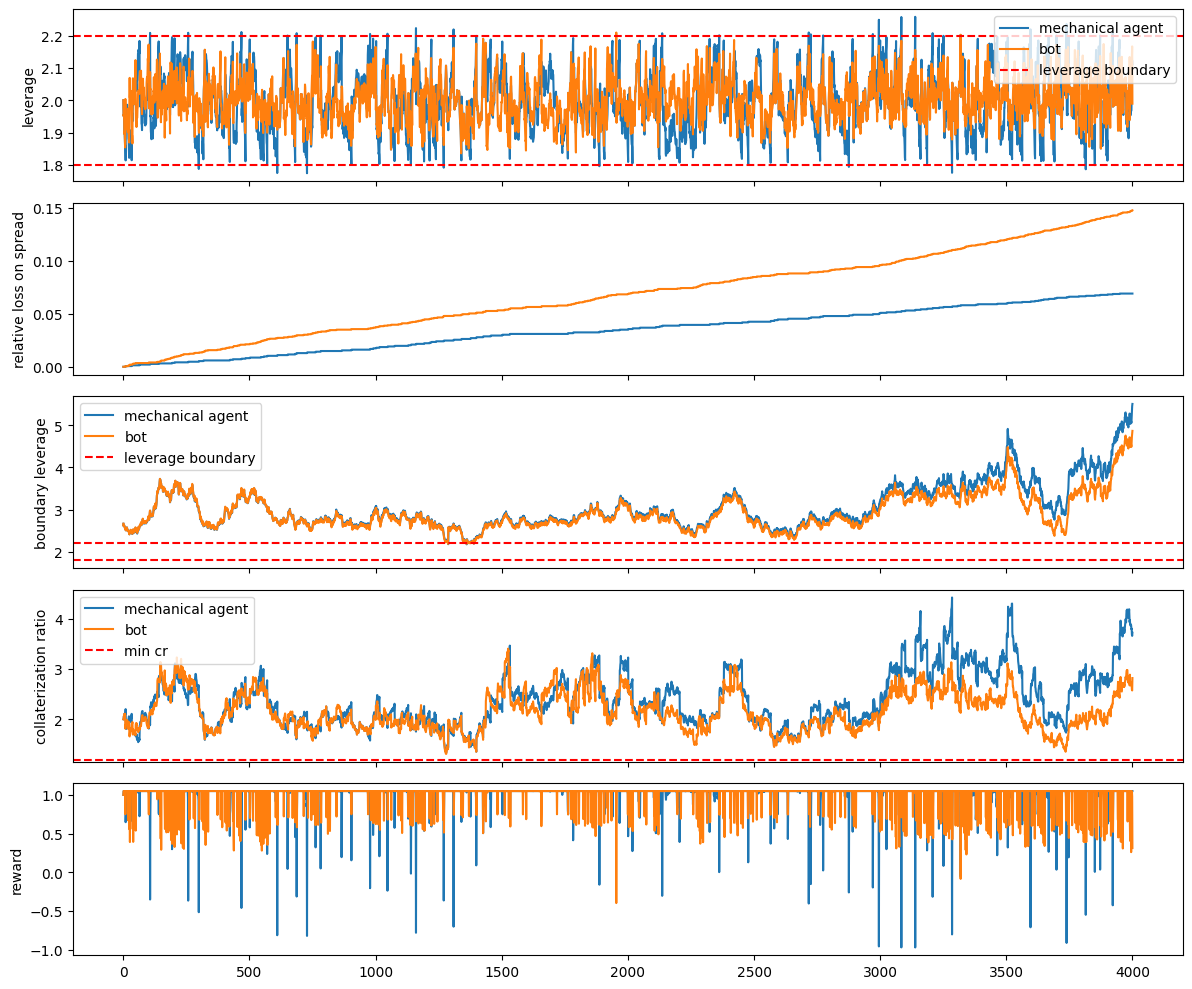

In [16]:
eval_env = agentDLVEnvV3(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_training = False,
    is_mixed = False,
    is_reversed = False,
    show_setup = False,
    top_leverage= 2.2,
    bottom_leverage = 1.8
)

obs, _ = eval_env.reset()
done = False
hidden = model.init_hidden(batch_size=1, device='cpu')

while not done:
    action, log_prob, _, hidden = model.act(obs, hidden)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

history_bot = info['episode_history']
not_doing = info.get('0 action')  
action_1 = info.get('0.5 rebalancing') 
action_2 = info.get('0.75 rebalancing') 
action_3 = info.get('0.25 rebalancing') 

print('doing nothing', not_doing*100, '%')
print('action 1', action_1*100, '%')
print('action 2', action_2*100, '%')
print('action 3', action_3*100, '%')

t_l = info['top leverage']
b_l = info['bottom leverage']
plot_episode_history_v2([history_agent, history_bot],['mechanical agent', 'bot'], t_l, b_l)